<a href="https://colab.research.google.com/github/thegrimeater/hw_linear_models_li_sergey/blob/main/li_sergey_hw_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание по теме "Линейные модели"

В этом задании мы поработаем с линейной и логистической регрессией на реальных наборах данных, будем пользоваться библиотекой scikit-learn. Ссылка на документацию: https://scikit-learn.org/stable/index.html

В некоторых местах этого ноутбука код не дописан, на этом месте стоит "# YOUR CODE HERE". В этих местах вам нужно дописать код самостоятельно

## Линейная регрессия

Линейная регрессия - один из представителей класса линейных моделей, использующихся для решения задач регрессии. Суть алгоритма заключается в умножении каждого признака на некоторое число - **вес** данного признака.

Модель вырабатывает прогноз следующим образом: $$
\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n
$$
Здесь $x$ - числовые признаки объекта, $w$ - веса (параметры) модели, $\hat{y}$ - итоговое предсказание

Одна из целей этого ноутбука — познакомить вас с fit-predict (fit-transform) интерфейсом, типичным для многих реализаций моделей машинного обучения и для различных инструментов работы с данными.

Множество фреймворков машинного обучения (например, scikit-learn, CatBoost) содержат в себе модели и алгоритмы, которые описаны в виде классов, у которых есть два ключевых метода: fit и predict (transform). Давайте разберёмся, что делают эти методы.

***fit*** — метод для обучения алгоритма. Он получает на входе данные и таргеты для обучения, после чего обновляет состояние класса. После использования метода fit считается, что объект класса готов к использованию. Внутри этого метода может быть что угодно: обучение модели, подбор гиперпараметров, подсчет статистик и т. д.

***predict*** — метод для предсказания , обученного с помощью _fit_. В задаче регрессии это оценка параметра, в задаче классификации предсказанный класс.

***transform*** — стилистический синоним _predict_, но используется в классах, которые реализуют преобразования данных, например, масштабирование признаков или кодирование категориальных фичей.

***fit_transform*** — метод который учится на данных, а потом их же преобразовывает.

Ссылка на документацию по линейной регрессии: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

Здесь можно почитать информация о том, какие параметры у неё есть, посмотреть примеры использования, возвращаться к ней, если что-то непонятно

Переходим к практике

### Сгенерируем данные

Сгенерируем данные, выглядящие как линейные, для проверки этого уравнения.
Используем 100 примеров (m = 100), диапазон значений X - от 0 до 2, $y = 4 + 3 * x +$ случайный шум в данных

In [ ]:
import numpy as np

np.random.seed(42)  # to make this code example reproducible
m = 100  # number of instances
X = 2 * np.random.rand(m, 1)  # column vector
y = 4 + 3 * X + np.random.randn(m, 1)  # column vector

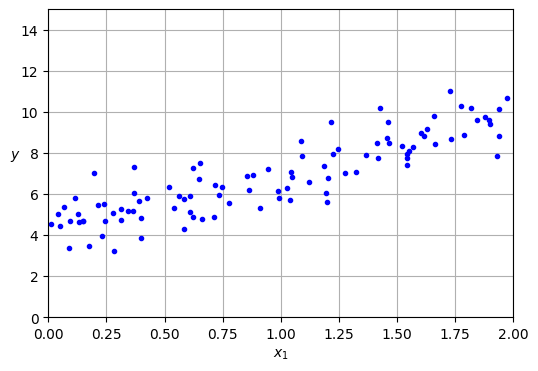

In [ ]:
# Визуализируем данные

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

Воспользуемся готовой реализацией scikit-learn: обучим модель на наших данных и посмотрим на результат

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

Посмотрим на веса нашей модели

In [ ]:
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

Как видим, получившиеся веса модели близки к весам из нашего уравнения - 4 и 3

Получим предсказание модели на двух конкретном примере

In [ ]:
X_sample = np.array([[0], [2]]) # Первый пример - 0, второй - 2
y_sample = lin_reg.predict(X_sample)
y_sample

array([[4.21509616],
       [9.75532293]])

Сделаем предсказания моделью на всём наборе данных

In [ ]:
y_predict = lin_reg.predict(X)

Визуализируем нашу модель

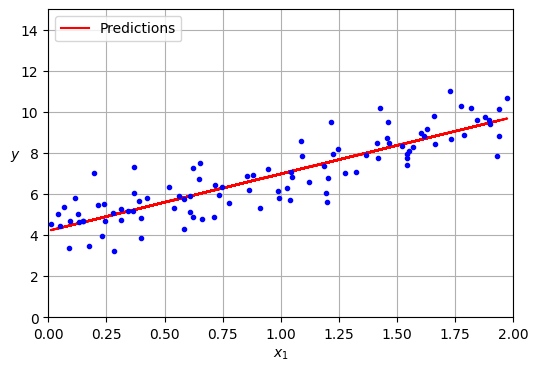

In [ ]:
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(X, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
plt.show()

Как видим, модель достаточно точно подстроилась под наши данные

### Реальный набор данных

Теперь поработаем с реальным набором данных - цены на жильё в Калифорнии. В этот раз наша задача будет предсказать цену жилья, используя различную информацию о нём

Загрузка данных

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

/tmp/ipykernel_2078/2839428726.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


Посмотрим на некоторые примеры из датасета

In [ ]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Объяснение переменных


*   **longitude** - долгота точки, где находится дом
*   **latitude** - широта точки, где находится дом
*   **housing_median_age** - медианный возраст домов в районе
Если значение = 30 — значит половина домов старше 30 лет, половина — младше.
*   **total_rooms** - общее количество комнат во всех домах района
*   **total_bedrooms** - общее количество спален во всех домах района
*   **population** - общее количество людей, проживающих в районе
*   **households** - количество домохозяйств
*   **median_income** - медианный доход жителей района (в десятках тысяч долларов)
*   **median_house_value** - медианная стоимость домов в районе (целевая переменная). Это и есть то, что мы пытаемся предсказывать
*   **ocean_proximity** - категориальный признак: расстояние региона до океана.
Значения такие:
"NEAR BAY" — рядом с заливом (Bay Area),
"NEAR OCEAN" — прямо у океана,
"INLAND" — внутри континента, далеко от океана,
"ISLAND" — остров,
"1H OCEAN" — примерно в 1 часе езды от океана

Визуализируем данные, исходи из долготы и широты

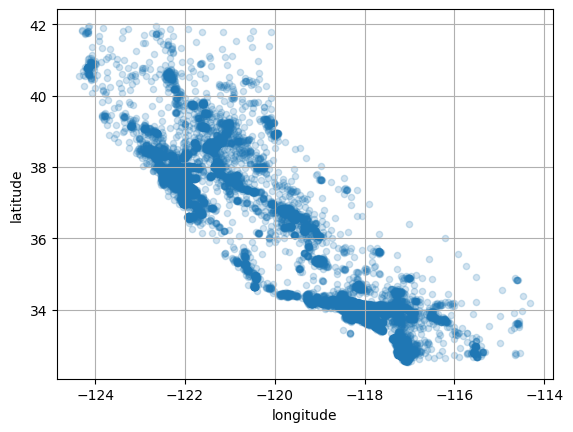

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2);

Сделаем улучшенную визуалзиацию, добавив информацию о населённости района и цене жилья

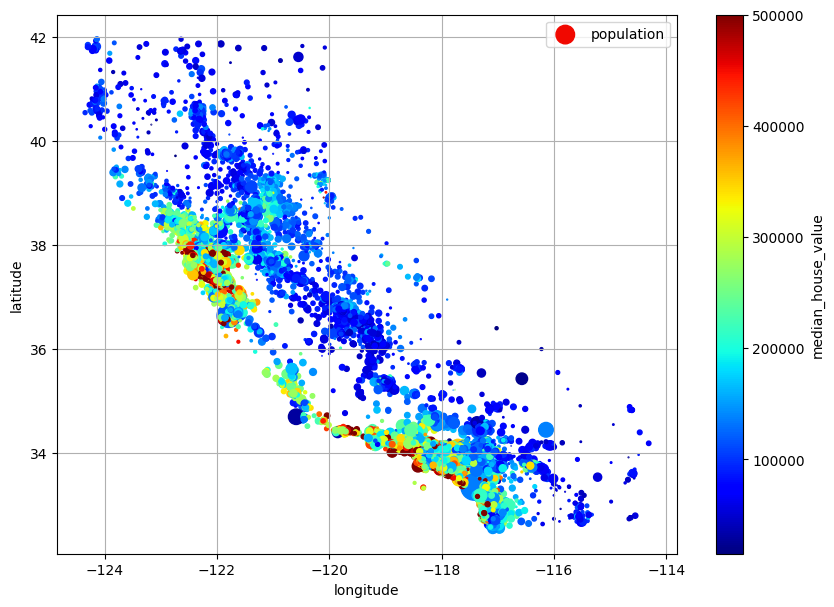

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7));

Для простоты оставим только числовые признаки, удалим категориальный признак "ocean_proximity"

In [ ]:
housing_num = housing.drop(['ocean_proximity'], axis=1)

Проверим датасет на наличие пропусков

In [ ]:
housing_num.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0


Как видим, в столбце `total_bedrooms` присутствуют пропуски (значение NaN). Существуют различные методы борьбы с ними, которые мы изучим в дальнейшем. Сейчас воспользуемся самым простым методом: просто удалим примеры, в котоорых встречаются пропуски

In [ ]:
housing_not_nan = housing_num.dropna()

Разделим нашу выборку на 2 части: тренировочную и тестовую

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_not_nan, test_size=0.2, random_state=42)

In [ ]:
y_train = train_set['median_house_value']
y_test = test_set['median_house_value']

Выполним преобразование над нашими данными - *стандартизируем* их, то есть приведём их к одному масштабу.

In [ ]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
train_set_scaled = std_scaler.fit_transform(train_set.drop(['median_house_value'], axis=1))
test_set_scaled = std_scaler.transform(test_set.drop(['median_house_value'], axis=1))

Загрузим модель линейной регрессии в переменную model

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

Обучим модель на наших обучающих данных

In [ ]:
model.fit(train_set_scaled, y_train)

LinearRegression()

Получим предсказания модели на тестовом наборе данных

In [ ]:
y_test_pred = model.predict(test_set_scaled)

Оценим качество работы модели с помощью функции Mean Absolute Error (MAE).

Документация, можно посмотреть, как пользоваться: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html

In [ ]:
from sklearn.metrics import mean_absolute_error

MAE = mean_absolute_error(y_test_pred, y_test)

MAE

51391.166407090575

### Регуляризация моделей

Проделаем всё то же самое (загрузка модели, обучение на обучающем наборе, предсказание на тестовом наборе, подсчёт метрики MAE), но используя регуляризированную версию модели

#### Ridge

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

distribution = dict(alpha=loguniform(1e-4, 1e3))
model = Ridge()

reg = RandomizedSearchCV(Ridge(), distribution,
                           scoring="neg_mean_absolute_error", n_iter=50)
search = reg.fit(train_set_scaled, y_train)
search.best_params_

model = Ridge(alpha=14.463106196326054)
model.fit(train_set_scaled, y_train)

y = model.predict(test_set_scaled)

MAE = mean_absolute_error(y, y_test)
MAE

51391.24955552992

### Lasso

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

distribution = dict(alpha=uniform(1, 100))
model = Lasso()

# reg = RandomizedSearchCV(Lasso(), distribution, n_iter=50)
# search = reg.fit(train_set_scaled, y_train)
# search.best_params_

model = Lasso(alpha=35.26534881209153)
model.fit(train_set_scaled, y_train)

y = model.predict(test_set_scaled)

MAE = mean_absolute_error(y, y_test)
MAE

51396.28357212376

### ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error

model = ElasticNetCV()
model.fit(train_set_scaled, y_train)

y_pred = model.predict(test_set_scaled)

MAE = mean_absolute_error(y_pred, y_test)
MAE

91185.125109552

Какая модель справилась с задачей лучше всего? Как вы думаете, с чем это связано?

Модели с регуляризацией и без справились с задачей с практически одинаковым успехом, т.к. регуляризация практически никак не повлияло на качество модели из-за малого количества признаков и большого кол-ва обучающих примеров

Переходим к логистической регрессии

# Логистическая регрессия

In [2]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "training_linear_models"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Логистическая регрессия (также называемая логит-регрессией (logit regression)) используется для оценки вероятности того, что образец принадлежит к определенному классу (например, какова вероятность того, что заданное почтовое сообщение является спамом?). Это делает ее двоичным классификатором.
Логистическая регрессия вычисляет эту вероятность следующим образом:
$$
P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}
$$
Где
$$
\sigma(z) = \frac{1}{1 + e^{-z}} -
$$
функция сигмоида

Saving figure logistic_function_plot


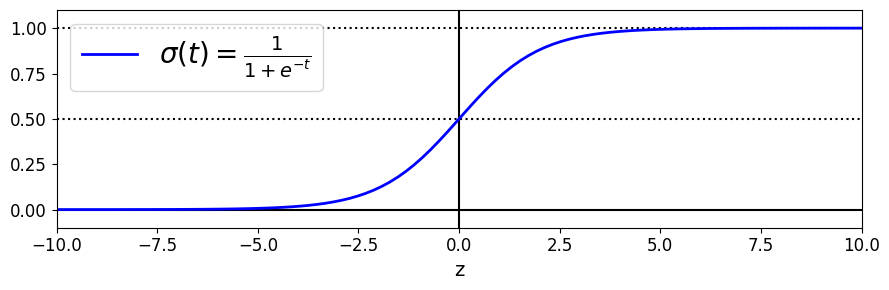

In [3]:
z = np.linspace(-10, 10, 100)
sig = 1 / (1 + np.exp(-z))
plt.figure(figsize=(9, 3))
plt.plot([-10, 10], [0, 0], "k-")
plt.plot([-10, 10], [0.5, 0.5], "k:")
plt.plot([-10, 10], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(z, sig, "b-", linewidth=2, label=r"$\sigma(t) = \frac{1}{1 + e^{-t}}$")
plt.xlabel("z")
plt.legend(loc="upper left", fontsize=20)
plt.axis([-10, 10, -0.1, 1.1])
save_fig("logistic_function_plot")
plt.show()

После того как логистическая регрессионная модель оценила вероятность
р = (х), что образец х принадлежит положительному классу, она может
легко выработать прогноз у.

В sklearn при вызове метода predict модель вернёт класс "1", если вероятность p >= 0.5. При вызове predict_proba модель вернёт вероятность принадлежности объекта классу "1"

### Бинарная классификация

Чтобы продемонстрировать работу логистической регрессии, мы используем набор данных об ирисах. Это знаменитый набор данных, который содержит длины и ширины чашелистиков и лепестков цветков ириса трех разных видов: ирис щетинистый (iris setosa), ирис разноцветный (iris versicolor)
и ирис виргинский (iris virginica).
Попробуем построить классификатор для выявления вида ириса виргинского на основе только признака ширины лепестка (petal width). Сначала загрузим данные:

In [4]:
from sklearn import datasets
iris = datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [5]:
# Описание датасета
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [6]:
X = iris["data"][:, 3:]  # ширина лепеста
y = (iris["target"] == 2).astype(int)  # 1 if Ирис виргинский, else 0

Обучите модель логистической регрессии на наших данных

In [7]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X,y)

LogisticRegression()

Давайте взглянем на оценочные вероятности модели для цветов, ширина
лепестка которых варьируется от 0 до 3 сантиметров:

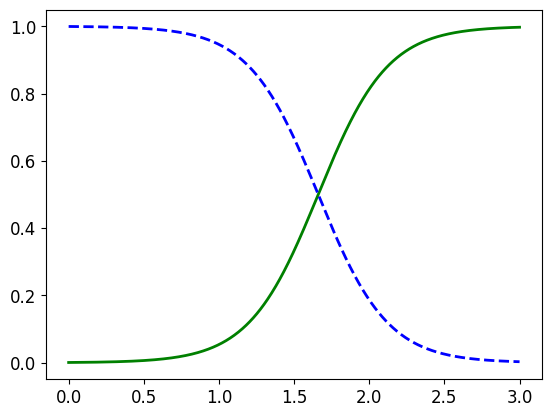

In [8]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
# предскажите вероятность принадлежности классу
y_proba = clf.predict_proba(X_new)

plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica")
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica")

Saving figure logistic_regression_plot


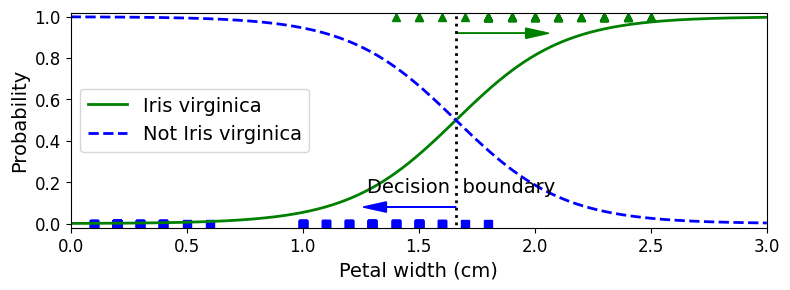

In [9]:
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0][0]

plt.figure(figsize=(8, 3))
plt.plot(X[y==0], y[y==0], "bs")
plt.plot(X[y==1], y[y==1], "g^")
plt.plot([decision_boundary, decision_boundary], [-1, 2], "k:", linewidth=2)
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica")
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica")
plt.text(decision_boundary+0.02, 0.15, "Decision  boundary", fontsize=14, color="k", ha="center")
plt.arrow(decision_boundary, 0.08, -0.3, 0, head_width=0.05, head_length=0.1, fc='b', ec='b')
plt.arrow(decision_boundary, 0.92, 0.3, 0, head_width=0.05, head_length=0.1, fc='g', ec='g')
plt.xlabel("Petal width (cm)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.legend(loc="center left", fontsize=14)
plt.axis([0, 3, -0.02, 1.02])
save_fig("logistic_regression_plot")
plt.show();

Обратите внимание на наличие некоторого перекрытия. Выше примерно 2 см классификатор весьма уверен в том, что цветок представляет собой ирис виргинский (он выдает высокую вероятность принадлежности к
данному классу), тогда как ниже 1 см он весьма уверен в том, что цветок
не является ирисом виргинским (высокая вероятность принадлежности к
классу "Не ирис виргинский"). В промежутке между указанными противо
 положностями классификатор не имеет уверенности. Тем не менее, если вы
предложите ему спрогнозировать класс {используя метод predict ( ) , а не
predict _proba ( ) ), то он возвратит любой класс как наиболее вероятный.
Следовательно, возле примерно 1.6 см существует граница решений (decision
boиndary), где обе вероятности равны 50%: если ширина лепестка больше
1.6 см, тогда классификатор спрогнозирует, что цветок - ирис виргинский, а
иначе - не ирис виргинский (хотя и не будучи очень уверенным):

In [10]:
clf.predict([[1.7], [1.5]])

array([1, 0])

На рис ниже показан тот же самый набор данных, но на этот раз с отображением двух признаков: ширина лепестка и длина лепестка. После обучения
классификатор, основанный на логистической регрессии, может оценивать
вероятность того, что новый цветок является ирисом виргинским, базируясь
на упомянутых двух признаках. Пунктирная линия представляет точки, где
модель производит оценку с 50%-ной вероятностью: это граница решений
модели. Обратите внимание, что граница линейна17. Каждая параллельная
линия представляет точки, в которых модель выдает специфическую вероят
 ность, от 15% {слева внизу) до 90% (справа вверху). В соответствии с моде
 лью все цветки выше правой верхней линии имеют более чем 90%-ный шанс
быть ирисом виргинским.
Подобно другим линейным моделям логистические регрессионные модели
могут быть регуляризированы с применением штрафов l1 или l2 . На самом
деле Scitkit-Learn по умолчанию добавляет штраф l2.

Гиперпараметром, управляющим силой регуляризации модели LogisticRegression из Scikit-Learn, является не alpha (как в других линейных модедях), а его инверсия: С. Чем выше значение С, тем меньше модель регуляризируется.

Saving figure logistic_regression_contour_plot


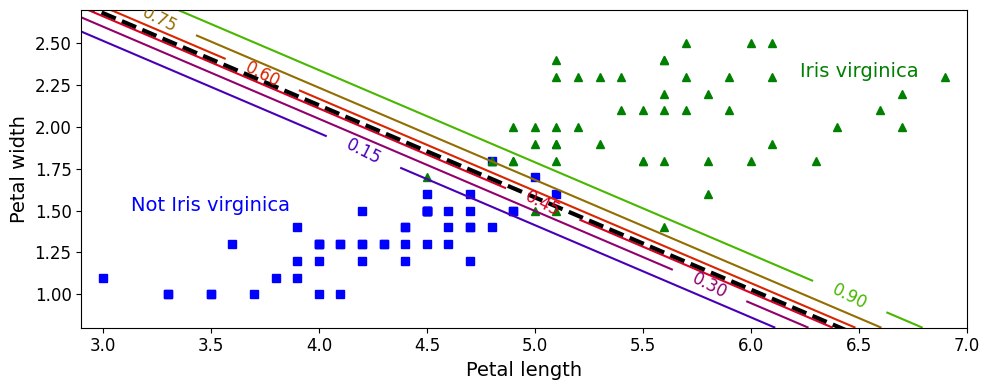

In [11]:
from sklearn.linear_model import LogisticRegression

X = iris["data"][:, (2, 3)]  # petal length, petal width
y = (iris["target"] == 2).astype(int)

log_reg = LogisticRegression(solver="lbfgs", C=10**10, random_state=42)
log_reg.fit(X, y)

x0, x1 = np.meshgrid(
        np.linspace(2.9, 7, 500).reshape(-1, 1),
        np.linspace(0.8, 2.7, 200).reshape(-1, 1),
    )
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = log_reg.predict_proba(X_new)

plt.figure(figsize=(10, 4))
plt.plot(X[y==0, 0], X[y==0, 1], "bs")
plt.plot(X[y==1, 0], X[y==1, 1], "g^")

zz = y_proba[:, 1].reshape(x0.shape)
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)


left_right = np.array([2.9, 7])
boundary = -(log_reg.coef_[0][0] * left_right + log_reg.intercept_[0]) / log_reg.coef_[0][1]

plt.clabel(contour, inline=1, fontsize=12)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.5, "Not Iris virginica", fontsize=14, color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", fontsize=14, color="g", ha="center")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.axis([2.9, 7, 0.8, 2.7])
save_fig("logistic_regression_contour_plot")
plt.show()

### Многоклассовая классификация

Логистическая регрессионная модель может быть обобщена для поддержки множества классов напрямую, без необходимости в обучении и комбинировании многочисленных двоичных классификаторов.

Идея довольно проста: имея образец х, многопеременная логистическая
регрессионная модель сначала вычисляет логиты $s_k(x)$ для каждого
класса k и затем оценивает вероятность каждого класса, применяя к суммам
очков многопеременную логистическую функцию (softmax function).

$$
s_k(x) = (\mathbf{w_k}^\top \mathbf{x} + b_k)
$$
Обратите внимание, что в данном случае каждый класс k имеет свой собственный вектор параметров $\mathbf{w_k}$

Функция sofrmax:
$$
\mathrm{softmax}(s_k) = \frac{e^{s_k}}{\sum_{j=1}^{K} e^{s_k}}, \quad i = 1, \ldots, K
$$
Эти значения можно интерпретировать как вероятности принадлежности классу k.

Подобно классификатору, основанному на логистической регрессии, классификатор на базе многопеременной логистической регрессии прогнозирует
класс с наивысшей оценочной вероятностью

Обучите модель логистической регрессии на трёх классах

In [24]:
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"].astype(int)

softmax_reg = LogisticRegression().fit(X, y)

Посмотрим на границы решений

Saving figure softmax_regression_contour_plot


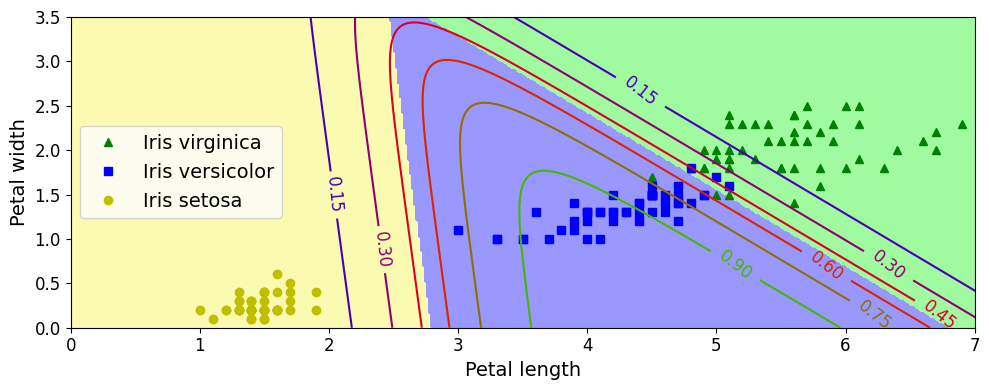

In [25]:
x0, x1 = np.meshgrid(
        np.linspace(0, 8, 500).reshape(-1, 1),
        np.linspace(0, 3.5, 200).reshape(-1, 1),
    )
X_new = np.c_[x0.ravel(), x1.ravel()]


y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y==2, 0], X[y==2, 1], "g^", label="Iris virginica")
plt.plot(X[y==1, 0], X[y==1, 1], "bs", label="Iris versicolor")
plt.plot(X[y==0, 0], X[y==0, 1], "yo", label="Iris setosa")

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap=plt.cm.brg)
plt.clabel(contour, inline=1, fontsize=12)
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="center left", fontsize=14)
plt.axis([0, 7, 0, 3.5])
save_fig("softmax_regression_contour_plot")
plt.show()

Обратите внимание, что границы решений
между любыми двумя классами линейны. На рис. 4.25 также приведены вероятности для класса "Ирис разноцветный", представленного кривыми линиями (скажем, линия с меткой 0.450 представляет границу 45%-ной вероятности). Имейте в виду, что модель способна прогнозировать класс, который
имеет оценочную вероятность ниже 50%. Например, в точке, где встречаются все границы решений, все классы имеют одинаковые оценочные вероятности 33%.

In [26]:
softmax_reg.predict([[5, 2]])

array([2])

In [27]:
softmax_reg.predict_proba([[5, 2]])

array([[2.43199208e-04, 2.14948752e-01, 7.84808048e-01]])